In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import seaborn as sns

from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(" All libraries imported successfully.")

 All libraries imported successfully.


In [2]:
df = pd.read_csv( r"E:/2ndYear2ndSemester/Project(DSMA299)/remittance-forecasting/output/remittance_2012_2025_model_ready.csv", parse_dates=['date'])
df = df.set_index('date')
df = df.sort_index()  # Make sure dates are in ascending order

print(f"Shape: {df.shape}  (rows × columns)")
print(f"Date range: {df.index.min().strftime('%b %Y')} → {df.index.max().strftime('%b %Y')}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

Shape: (151, 8)  (rows × columns)
Date range: May 2013 → Nov 2025

Column names:
['remittance', 'exchange_rate', 'oil_price', 'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock']

First 5 rows:


,remittance,exchange_rate,oil_price,dofe_departures,dofe_lag3,dofe_lag6,dofe_lag9,covid_shock
date,,,,,,,,
2013-05-01,40065.5,87.91,99.366633,54818.0,51516.0,34990.0,45417.0,0
2013-06-01,45815.2,93.02,99.742667,58937.0,55439.0,54304.0,38297.0,0
2013-07-01,46119.4,95.30,105.257905,59707.0,58054.0,57951.0,47067.0,0
2013-08-01,41867.3,98.26,108.157636,54134.0,54818.0,51516.0,34990.0,0
2013-09-01,46168.5,101.59,108.757730,32607.0,58937.0,55439.0,54304.0,0


In [3]:
print("Summary Statistics:")
df.describe().round(2)

Summary Statistics:


,remittance,exchange_rate,oil_price,dofe_departures,dofe_lag3,dofe_lag6,dofe_lag9,covid_shock
count,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00
mean,80975.40,115.59,69.51,51846.31,51576.83,51085.40,50491.79,0.06
std,33820.36,13.44,20.96,18565.51,18415.08,18186.35,17930.49,0.24
min,34516.81,87.91,21.04,0.00,0.00,0.00,0.00,0.00
25%,55128.58,103.81,53.60,45548.00,45548.00,44751.00,44008.50,0.00
50%,72418.96,114.30,68.20,54818.00,54702.00,54337.00,54090.00,0.00
75%,100180.83,128.78,82.26,64644.50,63969.00,62978.00,61928.50,0.00
max,201230.00,141.67,116.80,84226.00,84226.00,84226.00,84226.00,1.00


In [4]:
# ── 3a. Remittance lag features ───────────────────────────────────────────────
df['remittance_lag1'] = df['remittance'].shift(1)
df['remittance_lag2'] = df['remittance'].shift(2)
df['remittance_lag3'] = df['remittance'].shift(3)
df['remittance_lag6'] = df['remittance'].shift(6)

# ── 3b. Time and seasonality features ────────────────────────────────────────
df['time_index'] = np.arange(len(df))   # 0, 1, 2, ... 150
df['month']      = df.index.month        # 1 = January, 12 = December

# ── 3c. Target variables (future values) ─────────────────────────────────────
df['target_1m'] = df['remittance'].shift(-1)   # 1 month ahead
df['target_3m'] = df['remittance'].shift(-3)   # 3 months ahead
df['target_6m'] = df['remittance'].shift(-6)   # 6 months ahead

# ── Drop rows with NaN in any target ─────────────────────────────────────────
# (The last 6 rows will have NaN in target_6m after the shift)
df_model = df.dropna(subset=['remittance_lag1', 'remittance_lag2',
                               'remittance_lag3', 'remittance_lag6'])

print(f"Original rows: {len(df)}")
print(f"After dropping NaN rows: {len(df_model)}")
print(f"Date range after cleaning: {df_model.index.min().strftime('%b %Y')} → {df_model.index.max().strftime('%b %Y')}")
print(f"\nNew columns added:")
new_cols = ['remittance_lag1','remittance_lag2','remittance_lag3','remittance_lag6',
            'time_index','month','target_1m','target_3m','target_6m']
print(df_model[new_cols].head(8).round(1))

Original rows: 151
After dropping NaN rows: 145
Date range after cleaning: Nov 2013 → Nov 2025

New columns added:
            remittance_lag1  remittance_lag2  remittance_lag3  \
date                                                            
2013-11-01          46998.1          46168.5          41867.3   
2013-12-01          43860.2          46998.1          46168.5   
2014-01-01          42283.1          43860.2          46998.1   
2014-02-01          44446.4          42283.1          43860.2   
2014-03-01          46283.1          44446.4          42283.1   
2014-04-01          44816.5          46283.1          44446.4   
2014-05-01          41075.7          44816.5          46283.1   
2014-06-01          46678.2          41075.7          44816.5   

            remittance_lag6  time_index  month  target_1m  target_3m  \
date                                                                   
2013-11-01          40065.5           6     11    42283.1    46283.1   
2013-12-01        

In [5]:
FEATURES = [
    'exchange_rate', 'oil_price', 'dofe_departures',
    'dofe_lag3', 'dofe_lag6', 'dofe_lag9',
    'covid_shock', 'month', 'time_index',
    'remittance_lag1', 'remittance_lag2', 'remittance_lag3', 'remittance_lag6'
]

TARGETS = ['target_1m', 'target_3m', 'target_6m']

# ── Split dates (matching team's split) ───────────────────────────────
TRAIN_END  = '2022-12-31'
CALIB_END  = '2023-12-31'
TEST_START = '2024-01-01'

train      = df_model.loc[:'2022-12-31']
calib      = df_model.loc['2023-01-01':'2023-12-31']
test       = df_model.loc['2024-01-01':]

# XGBoost trains on train + calib combined
train_full = pd.concat([train, calib])

# For conformal prediction — calib is the calibration set
cal_train  = train
cal_set    = calib

print(f"Train:       {train.index.min().strftime('%b %Y')} → {train.index.max().strftime('%b %Y')} ({len(train)} rows)")
print(f"Calibration: {calib.index.min().strftime('%b %Y')} → {calib.index.max().strftime('%b %Y')} ({len(calib)} rows)")
print(f"Test:        {test.index.min().strftime('%b %Y')} → {test.index.max().strftime('%b %Y')} ({len(test)} rows)")

train_ceiling = train_full['remittance'].max()
test_max      = test['remittance'].max()
exceed_count  = (test['remittance'] > train_ceiling).sum()

print(f"\n  Training ceiling: {train_ceiling:,.0f}")
print(f"   Test max:         {test_max:,.0f}")
print(f"   Months above ceiling: {exceed_count} of {len(test)}")

Train:       Nov 2013 → Dec 2022 (110 rows)
Calibration: Jan 2023 → Dec 2023 (12 rows)
Test:        Jan 2024 → Nov 2025 (23 rows)

  Training ceiling: 136,968
   Test max:         201,230
   Months above ceiling: 10 of 23


In [6]:
XGB_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

X_test_full = test[FEATURES]
models = {}
predictions = {}

for target_col in TARGETS:
    # Drop NaN rows for this specific horizon
    train_h = train_full.dropna(subset=[target_col])
    test_h  = test.dropna(subset=[target_col])
    
    X_train = train_h[FEATURES]
    y_train = np.log(train_h[target_col])
    X_test  = test_h[FEATURES]
    
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    y_pred = np.exp(model.predict(X_test))
    
    models[target_col]      = model
    predictions[target_col] = (test_h.index, y_pred)
    
    print(f" Trained model for {target_col} ({len(test_h)} test rows)")

print("\nAll three models trained successfully.")

 Trained model for target_1m (22 test rows)
 Trained model for target_3m (20 test rows)
 Trained model for target_6m (17 test rows)

All three models trained successfully.


In [7]:
alpha = 0.10  # 90% prediction intervals

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def winkler_score(y_true, lower, upper, alpha):
    width   = upper - lower
    penalty = np.where(y_true < lower, (2 / alpha) * (lower - y_true),
              np.where(y_true > upper, (2 / alpha) * (y_true - upper), 0))
    return np.mean(width + penalty)

results = []

for target_col in TARGETS:
    test_idx, y_pred = predictions[target_col]
    y_true = test.loc[test_idx, target_col].values
    # ── Point metrics ──────────────────────────────────────────────────────────
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val  = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)


    # ── Conformal prediction intervals ─────────────────────────────────────────
    model_conf = XGBRegressor(**XGB_PARAMS)
    model_conf.fit(cal_train[FEATURES], np.log(cal_train[target_col]))
    cal_pred  = np.exp(model_conf.predict(cal_set[FEATURES]))
    residuals = np.abs(cal_set[target_col].values - cal_pred)

    q_level = min(np.ceil((1 - alpha) * (len(residuals) + 1)) / len(residuals), 1.0)
    q_hat   = np.quantile(residuals, q_level)

    lower    = y_pred - q_hat
    upper    = y_pred + q_hat
    coverage = np.mean((y_true >= lower) & (y_true <= upper)) * 100
    w_score  = winkler_score(y_true, lower, upper, alpha)

    horizon_label = target_col.replace('target_', '').upper()
    results.append({
        'Horizon':       horizon_label,
        'RMSE':          round(rmse_val, 1),
        'MAE':           round(mae_val,  1),
        'MAPE (%)':      round(mape_val, 2),
        'R²':            round(r2_val, 4),
        'Coverage (%)':  round(coverage, 1),
        'Winkler Score': round(w_score,  1)
    })

    print(f"Horizon {horizon_label}:  RMSE = {rmse_val:>12,.1f}  |  MAE = {mae_val:>12,.1f}  "
          f"|  MAPE = {mape_val:.2f}%  |  Coverage = {coverage:.1f}%  |  Winkler = {w_score:,.1f}")

results_df = pd.DataFrame(results).set_index('Horizon')

print("\n" + "="*60)
print("FULL RESULTS")
print("="*60)
print(results_df)

Horizon 1M:  RMSE =     31,481.2  |  MAE =     22,757.5  |  MAPE = 14.18%  |  Coverage = 72.7%  |  Winkler = 172,168.0
Horizon 3M:  RMSE =     36,556.2  |  MAE =     25,866.0  |  MAPE = 15.48%  |  Coverage = 70.0%  |  Winkler = 236,354.8
Horizon 6M:  RMSE =     35,927.7  |  MAE =     26,254.1  |  MAPE = 15.48%  |  Coverage = 64.7%  |  Winkler = 257,104.1

FULL RESULTS
            RMSE      MAE  MAPE (%)      R²  Coverage (%)  Winkler Score
Horizon                                                                 
1M       31481.2  22757.5     14.18 -0.4004          72.7       172168.0
3M       36556.2  25866.0     15.48 -0.9484          70.0       236354.8
6M       35927.7  26254.1     15.48 -0.8554          64.7       257104.1


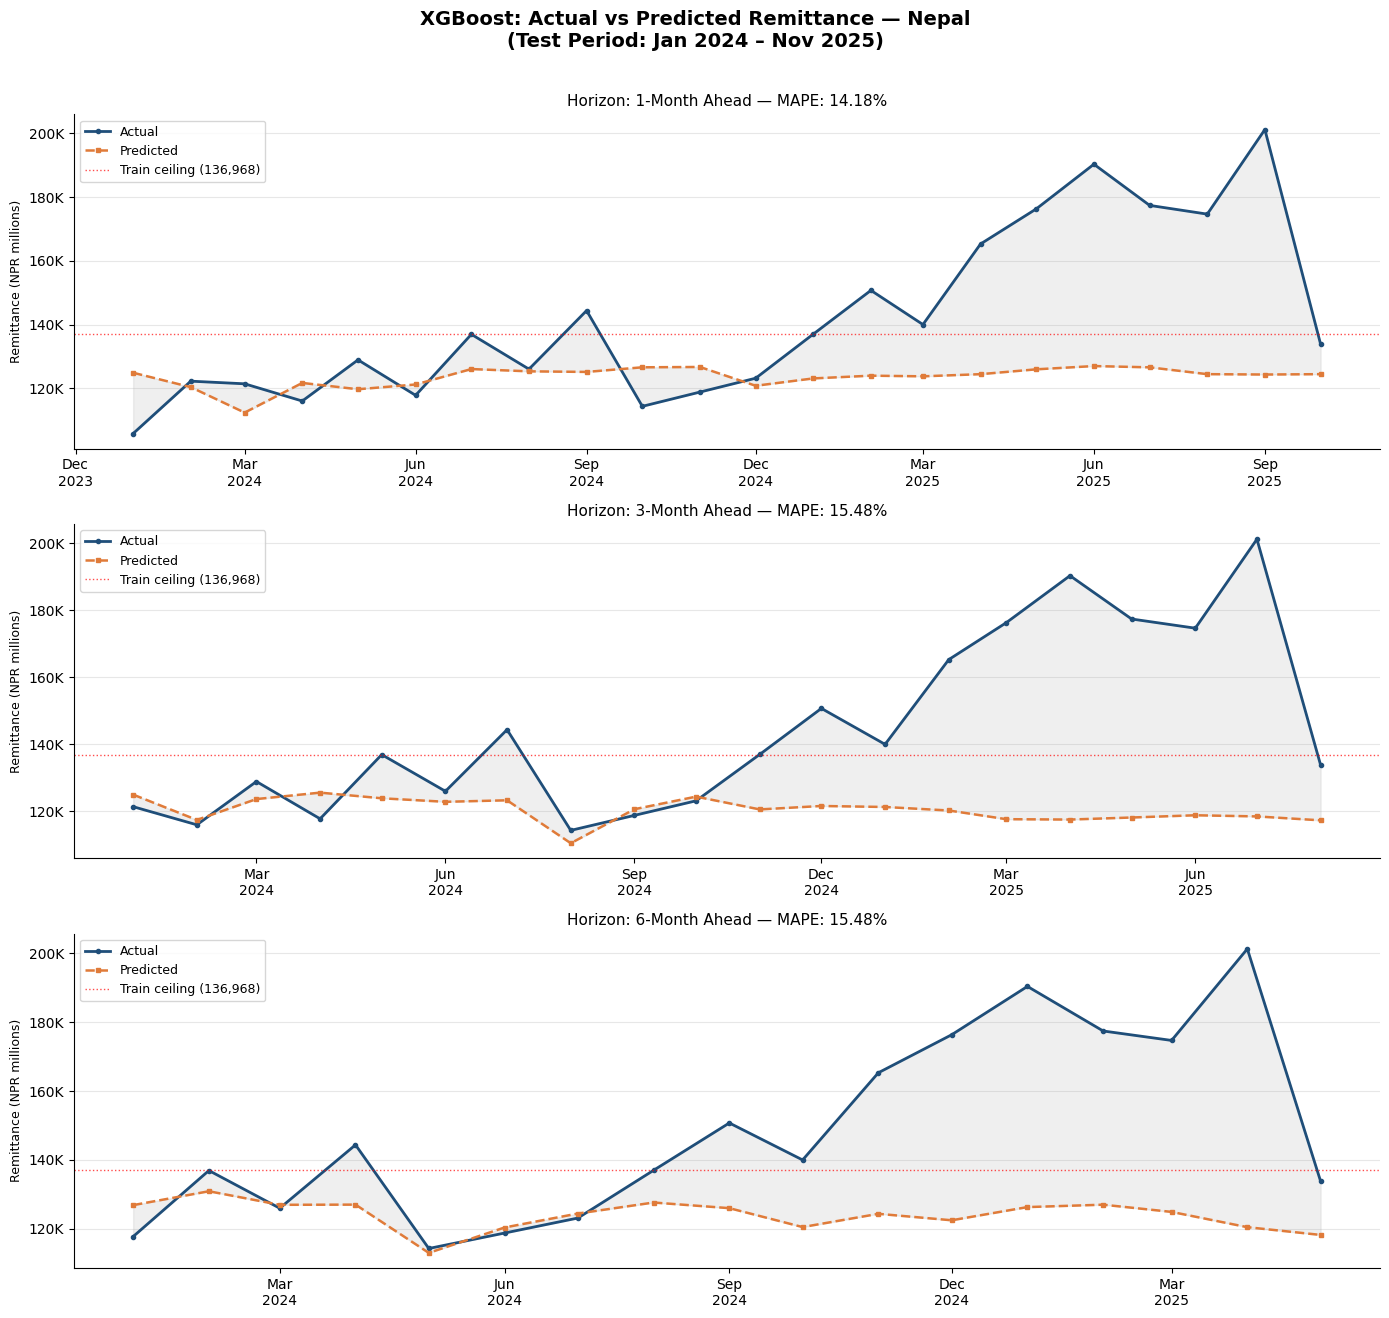

In [8]:
horizon_labels = {'target_1m': '1-Month Ahead', 'target_3m': '3-Month Ahead', 'target_6m': '6-Month Ahead'}

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)
fig.suptitle('XGBoost: Actual vs Predicted Remittance — Nepal\n(Test Period: Jan 2024 – Nov 2025)',
             fontsize=14, fontweight='bold', y=1.01)

colors = {'actual': '#1f4e79', 'predicted': '#e07b39'}

for ax, target_col in zip(axes, TARGETS):
    test_idx, y_pred = predictions[target_col]
    test_h = test.loc[test_idx]
    y_true = test_h[target_col]
    mape_v = mape(y_true.values, y_pred)
    
    ax.plot(test_h.index, y_true.values,
            color=colors['actual'], linewidth=2.0, label='Actual',
            marker='o', markersize=3)
    ax.plot(test_h.index, y_pred,
            color=colors['predicted'], linewidth=1.8, label='Predicted',
            marker='s', markersize=3, linestyle='--')
    
    ax.fill_between(test_h.index, y_true.values, y_pred,
                    alpha=0.12, color='gray')
    
    ax.axhline(y=train_ceiling, color='red', linewidth=1.0,
               linestyle=':', alpha=0.7,
               label=f'Train ceiling ({train_ceiling:,.0f})')
    
    ax.set_title(f"Horizon: {horizon_labels[target_col]} — MAPE: {mape_v:.2f}%", fontsize=11)
    ax.set_ylabel('Remittance (NPR millions)', fontsize=9)
    ax.legend(fontsize=9, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

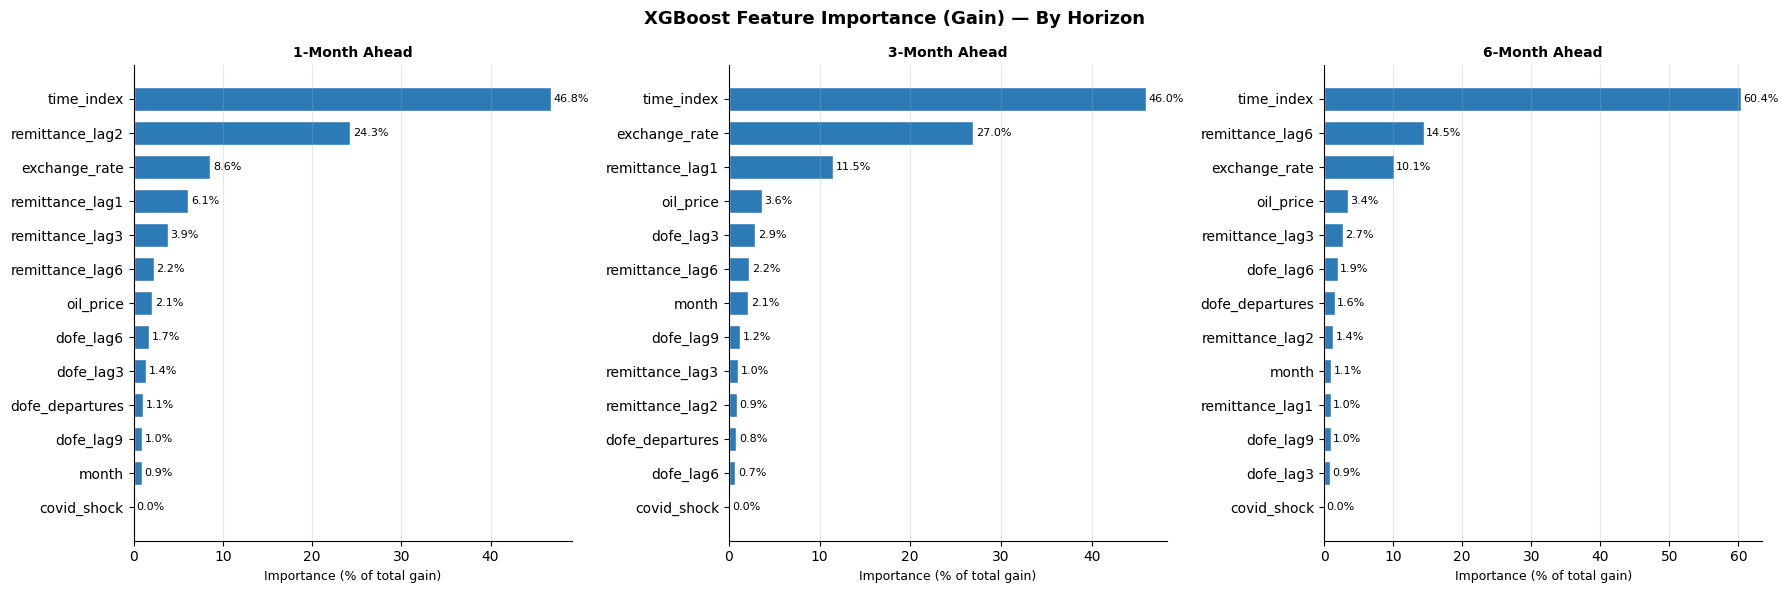

Chart saved as 'xgboost_feature_importance.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('XGBoost Feature Importance (Gain) — By Horizon', fontsize=13, fontweight='bold')

for ax, target_col in zip(axes, TARGETS):
    model = models[target_col]
    
    # Get importance scores
    importance = model.get_booster().get_score(importance_type='gain')
    imp_df = pd.DataFrame(importance.items(), columns=['Feature', 'Gain'])
    imp_df = imp_df.sort_values('Gain', ascending=True)
    
    # Normalise to 0–100 for easier reading
    imp_df['Gain_pct'] = imp_df['Gain'] / imp_df['Gain'].sum() * 100
    
    # Plot horizontal bar chart
    bars = ax.barh(imp_df['Feature'], imp_df['Gain_pct'],
                   color='#2c7bb6', edgecolor='white', height=0.7)
    
    # Add value labels
    for bar, val in zip(bars, imp_df['Gain_pct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    
    horizon_label = horizon_labels[target_col]
    ax.set_title(f'{horizon_label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Importance (% of total gain)', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("Chart saved as 'xgboost_feature_importance.png'")

=== SHAP ANALYSIS ===



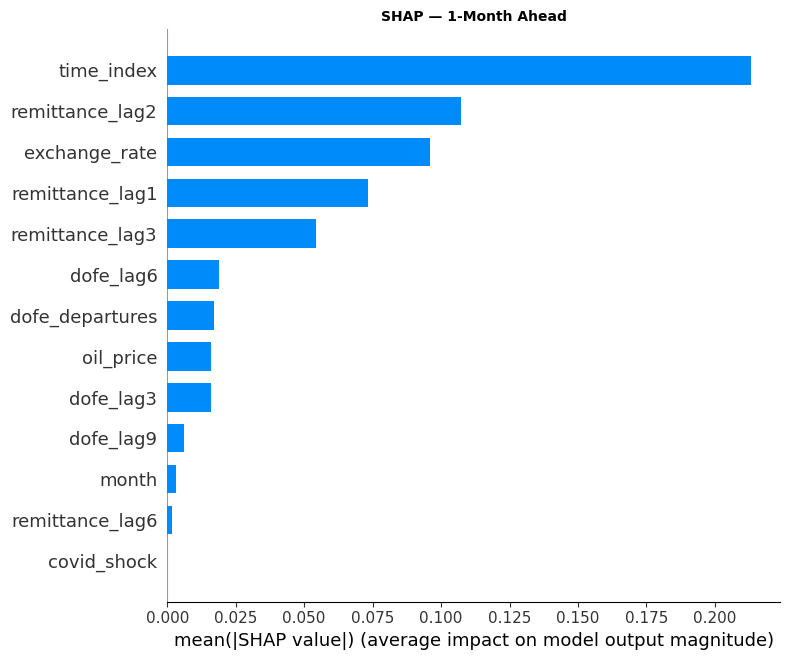

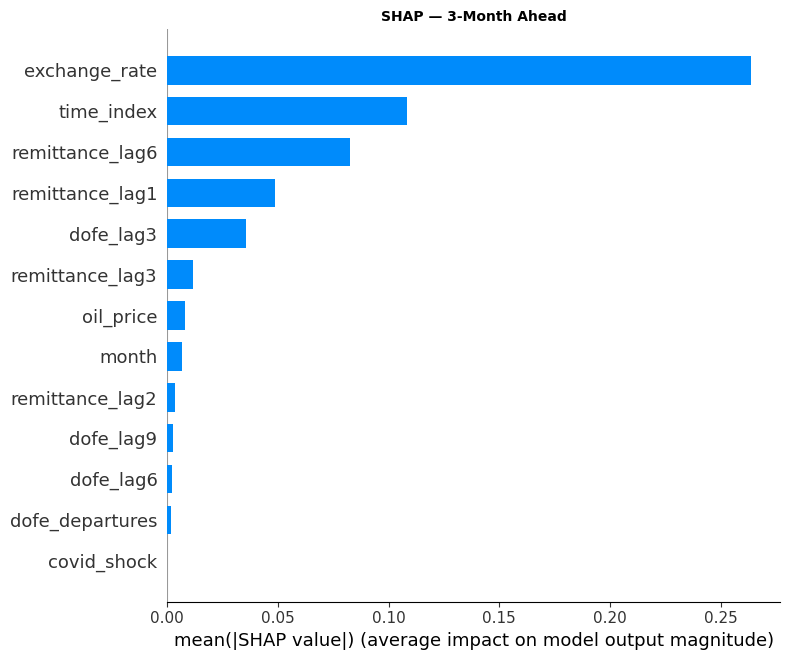

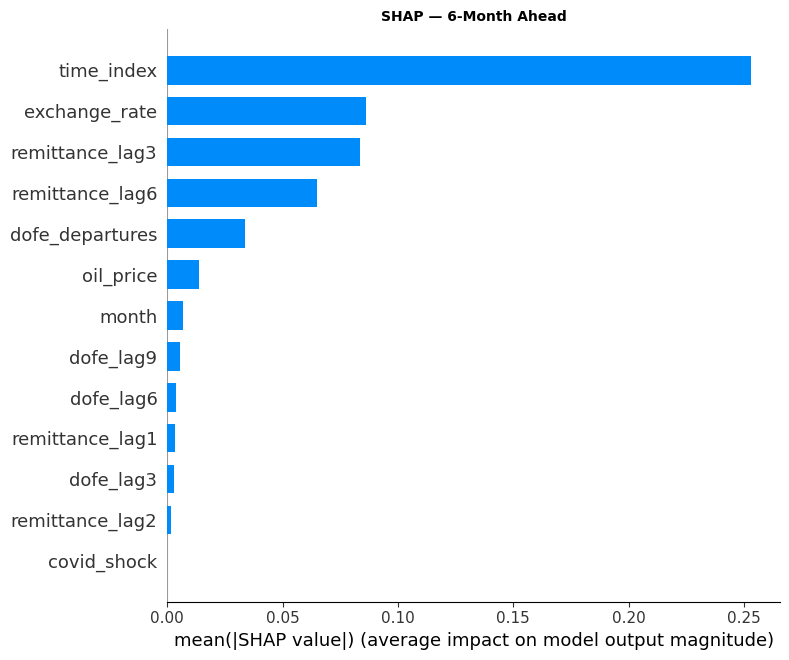

 SHAP analysis complete!


In [10]:
import shap

print("=== SHAP ANALYSIS ===\n")

for i, target_col in enumerate(TARGETS):
    explainer = shap.TreeExplainer(models[target_col])
    shap_values = explainer.shap_values(X_test)
    
    plt.figure(figsize=(8, 6))
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=FEATURES,
        show=False,
        plot_type='bar'
    )
    plt.title(f'SHAP — {horizon_labels[target_col]}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(" SHAP analysis complete!")

In [11]:
print("EXTRAPOLATION ANALYSIS")
print("=" * 55)
print(f"Training remittance ceiling: {train_ceiling:>12,.0f}")
print(f"Test set max remittance:     {test_max:>12,.0f}")
print(f"Test months above ceiling:   {exceed_count:>3} of {len(test)} ({exceed_count/len(test)*100:.0f}%)")
print()
print("Months where actual remittance exceeded training ceiling:")
exceeded = test[test['remittance'] > train_ceiling][['remittance']].copy()
exceeded['pct_above_ceiling'] = ((exceeded['remittance'] - train_ceiling) / train_ceiling * 100).round(1)
exceeded.index = exceeded.index.strftime('%b %Y')
exceeded.columns = ['Actual Remittance', '% Above Ceiling']
print(exceeded.to_string())

EXTRAPOLATION ANALYSIS
Training remittance ceiling:      136,968
Test set max remittance:          201,230
Test months above ceiling:    10 of 23 (43%)

Months where actual remittance exceeded training ceiling:
          Actual Remittance  % Above Ceiling
date                                        
Oct 2024           144380.0              5.4
Feb 2025           137000.0              0.0
Mar 2025           150730.0             10.0
Apr 2025           140000.0              2.2
May 2025           165300.0             20.7
Jun 2025           176320.0             28.7
Jul 2025           190340.0             39.0
Aug 2025           177410.0             29.5
Sep 2025           174670.0             27.5
Oct 2025           201230.0             46.9


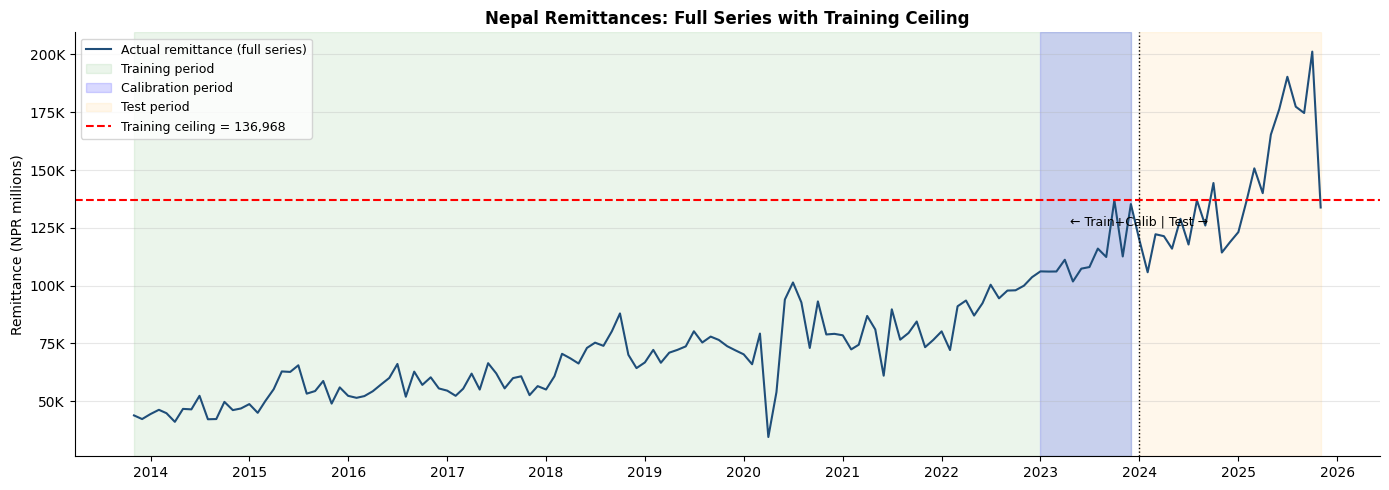

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
# Full time series
ax.plot(df_model.index, df_model['remittance'],
        color='#1f4e79', linewidth=1.5, label='Actual remittance (full series)')
# Training period shading
ax.axvspan(train_full.index.min(), train_full.index.max(), alpha=0.08, color='green', label='Training period')
# Calibration period shading
ax.axvspan(cal_set.index.min(), cal_set.index.max(), alpha=0.15, color='blue', label='Calibration period')
# Test period shading
ax.axvspan(test.index.min(), test.index.max(), alpha=0.08, color='orange', label='Test period')
# Training ceiling line
ax.axhline(y=train_ceiling, color='red', linewidth=1.5, linestyle='--',
           label=f'Training ceiling = {train_ceiling:,.0f}')
# Train/test boundary
ax.axvline(x=pd.Timestamp('2024-01-01'), color='black', linewidth=1, linestyle=':')
ax.text(pd.Timestamp('2024-01-01'), train_ceiling * 0.92, '← Train+Calib | Test →',
        fontsize=9, ha='center', color='black')
ax.set_title('Nepal Remittances: Full Series with Training Ceiling', fontsize=12, fontweight='bold')
ax.set_ylabel('Remittance (NPR millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(results_df.to_string())
print()
print("BENCHMARK COMPARISON (MAPE %)")
print("-" * 50)

mape_1m = results_df.loc['1M', 'MAPE (%)']
mape_3m = results_df.loc['3M', 'MAPE (%)']
mape_6m = results_df.loc['6M', 'MAPE (%)']

comparison = pd.DataFrame([
    {'Model': 'Ghimire (2026) XGBoost', 'Test Period': '2018–2023',        'MAPE (%)': 5.90,    'Note': 'Reference'},
    {'Model': 'Our XGBoost (1m ahead)', 'Test Period': 'Jan 2024–Nov 2025', 'MAPE (%)': mape_1m, 'Note': 'Extrapolation issue'},
    {'Model': 'Our XGBoost (3m ahead)', 'Test Period': 'Jan 2024–Nov 2025', 'MAPE (%)': mape_3m, 'Note': 'Extrapolation issue'},
    {'Model': 'Our XGBoost (6m ahead)', 'Test Period': 'Jan 2024–Nov 2025', 'MAPE (%)': mape_6m, 'Note': 'Extrapolation issue'},
]).set_index('Model')

print(comparison.to_string())

FINAL MODEL PERFORMANCE SUMMARY
            RMSE      MAE  MAPE (%)      R²  Coverage (%)  Winkler Score
Horizon                                                                 
1M       31481.2  22757.5     14.18 -0.4004          72.7       172168.0
3M       36556.2  25866.0     15.48 -0.9484          70.0       236354.8
6M       35927.7  26254.1     15.48 -0.8554          64.7       257104.1

BENCHMARK COMPARISON (MAPE %)
--------------------------------------------------
                              Test Period  MAPE (%)                 Note
Model                                                                   
Ghimire (2026) XGBoost          2018–2023      5.90            Reference
Our XGBoost (1m ahead)  Jan 2024–Nov 2025     14.18  Extrapolation issue
Our XGBoost (3m ahead)  Jan 2024–Nov 2025     15.48  Extrapolation issue
Our XGBoost (6m ahead)  Jan 2024–Nov 2025     15.48  Extrapolation issue


In [14]:
import os
os.makedirs("output", exist_ok=True)

for target_col, horizon in zip(TARGETS, ['1m', '3m', '6m']):
    test_idx, y_pred = predictions[target_col]
    y_true = test.loc[test_idx, target_col].values
    
    np.save(f"output/xgb_pred_{horizon}.npy", y_pred)
    np.save(f"output/xgb_true_{horizon}.npy", y_true)
    print(f"Saved {horizon}: {len(y_pred)} predictions")

print("\n All XGBoost predictions saved to output/")

Saved 1m: 22 predictions
Saved 3m: 20 predictions
Saved 6m: 17 predictions

 All XGBoost predictions saved to output/


In [15]:
print(test['target_1m'].isna().sum())
print(test['target_1m'].isna())

1
date
2024-01-01    False
2024-02-01    False
2024-03-01    False
2024-04-01    False
2024-05-01    False
2024-06-01    False
2024-07-01    False
2024-08-01    False
2024-09-01    False
2024-10-01    False
2024-11-01    False
2024-12-01    False
2025-01-01    False
2025-02-01    False
2025-03-01    False
2025-04-01    False
2025-05-01    False
2025-06-01    False
2025-07-01    False
2025-08-01    False
2025-09-01    False
2025-10-01    False
2025-11-01     True
Name: target_1m, dtype: bool
